In [11]:
# Import. Build. Measure.
import pandas as pd
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [12]:
# Load. Decode. Inspect.
url = "https://raw.githubusercontent.com/thejjeanjjorge/ml-datasets-models/refs/heads/main/knn/mushrooms.csv"
df = pd.read_csv(url)
display(df.head())
df.info()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [13]:
# Find. Count. Clarify.
print("Null values:", df.isna().sum().sum())
print("Unknown stalk roots:", (df["stalk-root"] == "?").sum())

Null values: 0
Unknown stalk roots: 2480


In [14]:
# Label. Separate. Preserve.
df = df.replace("?", "unknown")
X = df.drop(columns="class")
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
# Encode. Contain. Prevent leakage.
preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"),
     make_column_selector(dtype_include="object"))
])

In [16]:
# Tune. Cross-validate. Keep test sealed.
knn_search = GridSearchCV(
    Pipeline([("preprocess", preprocess), ("model", KNeighborsClassifier())]),
    {"model__n_neighbors": range(1, 10)},
    cv=5, scoring="accuracy", n_jobs=-1
)
knn_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x00000160FC3E6210>)])),
                                       ('model', KNeighborsClassifier())]),
             n_jobs=-1, param_grid={'model__n_neighbors': range(1, 10)},
             scoring='accuracy')

In [17]:
# Tune radius. Use meaningful distances.
radius_search = GridSearchCV(
    Pipeline([
        ("preprocess", preprocess),
        ("model", RadiusNeighborsClassifier(outlier_label="most_frequent"))
    ]),
    {"model__radius": [1, 2, 3, 4, 5]},
    cv=5, scoring="accuracy", n_jobs=-1
)
radius_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x00000160FC3E6210>)])),
                                       ('model',
                                        RadiusNeighborsClassifier(outlier_label='most_frequent'))]),
             n_jobs=-1, param_grid={'model__radius': [1, 2, 3, 4, 5]},
             scoring='accuracy')

In [18]:
# Compare validation. Select without test.
print(f"Best K: {knn_search.best_params_['model__n_neighbors']}")
print(f"KNN CV accuracy: {knn_search.best_score_:.4f}")
print(f"Best radius: {radius_search.best_params_['model__radius']}")
print(f"Radius CV accuracy: {radius_search.best_score_:.4f}")

final_model = max([knn_search, radius_search], key=lambda search: search.best_score_)

Best K: 1
KNN CV accuracy: 1.0000
Best radius: 2
Radius CV accuracy: 1.0000


In [19]:
# Test once. Report fully.
y_pred = final_model.predict(X_test)
print(f"Test accuracy: {final_model.score(X_test, y_test):.4f}")
print(classification_report(
    y_test, y_pred, labels=["e", "p"], target_names=["edible", "poisonous"]
))

Test accuracy: 1.0000
              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       842
   poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



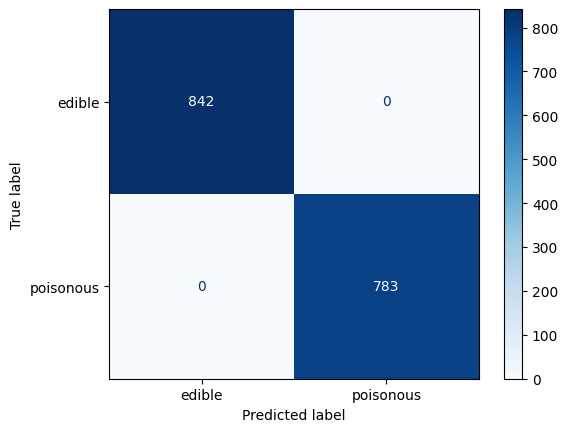

In [20]:
# Plot errors. Prioritize poison.
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=["e", "p"],
    display_labels=["edible", "poisonous"], cmap="Blues"
)